In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
fund = pd.read_csv("../data/processed/01_fund_master_clean.csv")

In [6]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [7]:
nav = nav.sort_values(["scheme_name", "date"])

nav["daily_return"] = nav.groupby("scheme_name")["nav"].pct_change()

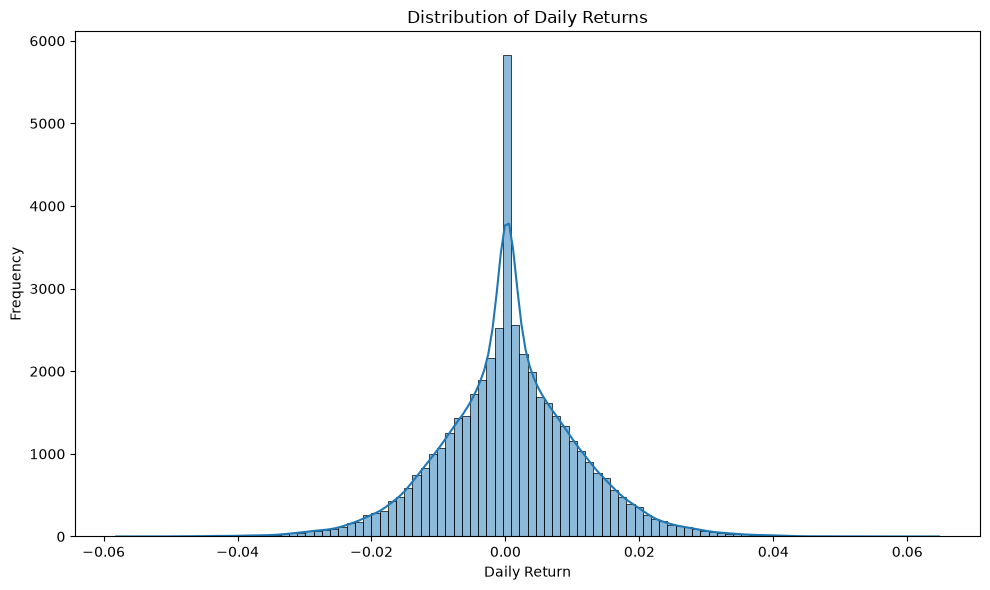

In [9]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100,
    kde=True
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../reports/charts/daily_return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

In [6]:
import pandas as pd

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
fund = pd.read_csv("../data/processed/01_fund_master_clean.csv")

nav["date"] = pd.to_datetime(nav["date"])

In [7]:
nav = nav.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [8]:
print(nav.columns)

Index(['amfi_code', 'date', 'nav', 'scheme_name'], dtype='str')


In [9]:
nav = nav.sort_values(["scheme_name", "date"])

In [10]:
def calculate_cagr(start_nav, end_nav, years):
    return ((end_nav / start_nav) ** (1 / years) - 1) * 100

In [11]:
results = []

for scheme, group in nav.groupby("scheme_name"):

    group = group.sort_values("date")

    start_nav = group.iloc[0]["nav"]
    end_nav = group.iloc[-1]["nav"]

    years = (group.iloc[-1]["date"] - group.iloc[0]["date"]).days / 365.25

    cagr = calculate_cagr(start_nav, end_nav, years)

    results.append({
        "scheme_name": scheme,
        "CAGR (%)": round(cagr, 2)
    })

cagr_df = pd.DataFrame(results)

cagr_df.head()

,scheme_name,CAGR (%)
0,ABSL Frontline Equity Fund - Regular - Growth,23.54
1,ABSL Liquid Fund - Regular - Growth,6.51
2,ABSL Small Cap Fund - Regular - Growth,7.94
3,Axis Bluechip Fund - Direct - Growth,7.90
4,Axis Bluechip Fund - Regular - Growth,6.37


In [12]:
cagr_df = cagr_df.sort_values(
    "CAGR (%)",
    ascending=False
)

cagr_df.head(10)

,scheme_name,CAGR (%)
18,ICICI Pru Midcap Fund - Regular - Growth,32.83
36,SBI Small Cap Fund - Regular Plan - Growth,32.42
8,DSP Small Cap Fund - Regular - Growth,32.29
26,Mirae Asset Tax Saver Fund - Regular - Growth,31.95
25,Mirae Asset Large Cap Fund - Regular - Growth,30.97
22,Kotak Flexicap Fund - Regular - Growth,30.91
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,30.12
7,DSP Midcap Fund - Regular - Growth,29.58
5,Axis Midcap Fund - Regular - Growth,28.21
33,SBI Bluechip Fund - Regular Plan - Growth,25.80


In [13]:
cagr_df.to_csv(
    "../reports/cagr_table.csv",
    index=False
)

### Insight 2

Funds with higher CAGR delivered stronger long-term growth over the analysis period, highlighting consistent wealth creation potential.

In [15]:
nav = nav.sort_values(["scheme_name", "date"])

nav["daily_return"] = (
    nav.groupby("scheme_name")["nav"]
       .pct_change()
)

In [16]:
import numpy as np

risk_free_rate = 0.065

sharpe_results = []

for scheme, group in nav.groupby("scheme_name"):

    returns = group["daily_return"].dropna()

    if len(returns) > 0:

        mean_return = returns.mean() * 252
        std_return = returns.std() * np.sqrt(252)

        sharpe = (mean_return - risk_free_rate) / std_return

        sharpe_results.append({
            "scheme_name": scheme,
            "Sharpe Ratio": round(sharpe, 3)
        })

sharpe_df = pd.DataFrame(sharpe_results)

sharpe_df.head()

,scheme_name,Sharpe Ratio
0,ABSL Frontline Equity Fund - Regular - Growth,1.027
1,ABSL Liquid Fund - Regular - Growth,-0.816
2,ABSL Small Cap Fund - Regular - Growth,0.163
3,Axis Bluechip Fund - Direct - Growth,0.130
4,Axis Bluechip Fund - Regular - Growth,0.031


In [17]:
sharpe_df = sharpe_df.sort_values(
    by="Sharpe Ratio",
    ascending=False
)

sharpe_df.head(10)

,scheme_name,Sharpe Ratio
25,Mirae Asset Large Cap Fund - Regular - Growth,1.448
22,Kotak Flexicap Fund - Regular - Growth,1.307
26,Mirae Asset Tax Saver Fund - Regular - Growth,1.235
33,SBI Bluechip Fund - Regular Plan - Growth,1.208
18,ICICI Pru Midcap Fund - Regular - Growth,1.180
7,DSP Midcap Fund - Regular - Growth,1.132
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.094
30,Nippon India Large Cap Fund - Regular - Growth,1.082
0,ABSL Frontline Equity Fund - Regular - Growth,1.027
15,ICICI Pru Bluechip Fund - Direct - Growth,1.027


In [18]:
sharpe_df.to_csv(
    "../reports/sharpe_ratio.csv",
    index=False
)

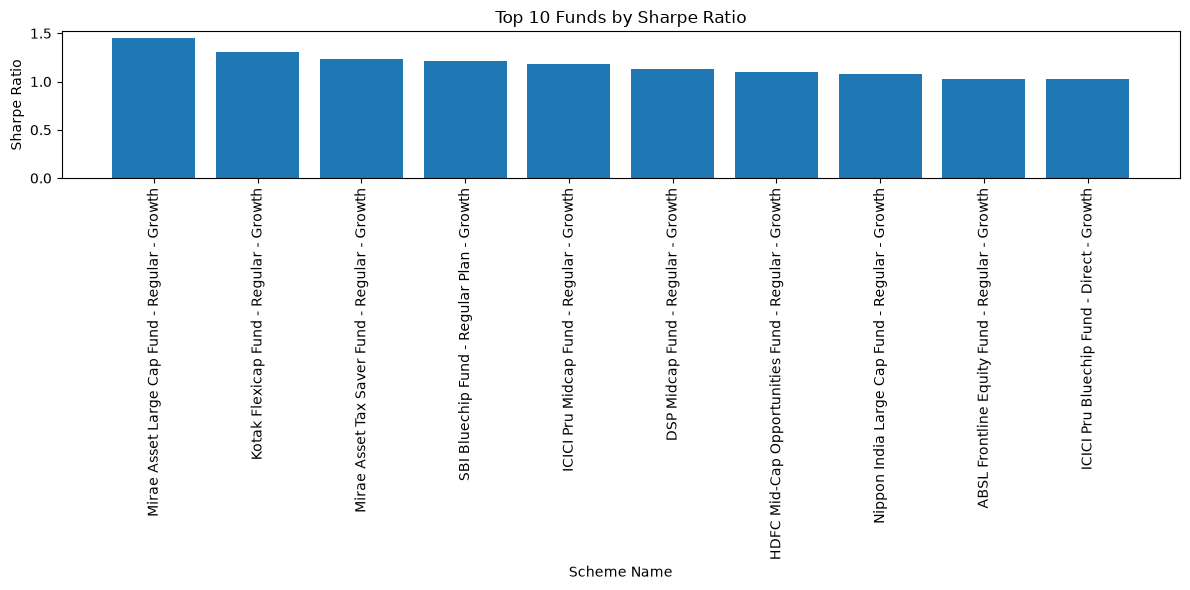

In [19]:
import matplotlib.pyplot as plt

top10 = sharpe_df.head(10)

plt.figure(figsize=(12,6))

plt.bar(top10["scheme_name"], top10["Sharpe Ratio"])

plt.xticks(rotation=90)
plt.title("Top 10 Funds by Sharpe Ratio")
plt.xlabel("Scheme Name")
plt.ylabel("Sharpe Ratio")

plt.tight_layout()

plt.savefig("../reports/charts/sharpe_ratio_top10.png", dpi=300)

plt.show()

### Insight 3

Funds with higher Sharpe Ratios delivered better risk-adjusted returns, indicating superior performance after accounting for volatility.

In [20]:
import numpy as np

risk_free_rate = 0.065

sortino_results = []

for scheme, group in nav.groupby("scheme_name"):

    returns = group["daily_return"].dropna()

    if len(returns) > 0:

        downside_returns = returns[returns < 0]

        if len(downside_returns) > 0:

            mean_return = returns.mean() * 252

            downside_std = downside_returns.std() * np.sqrt(252)

            sortino = (mean_return - risk_free_rate) / downside_std

        else:
            sortino = np.nan

        sortino_results.append({
            "scheme_name": scheme,
            "Sortino Ratio": round(sortino, 3)
        })

sortino_df = pd.DataFrame(sortino_results)

sortino_df.head()

,scheme_name,Sortino Ratio
0,ABSL Frontline Equity Fund - Regular - Growth,1.800
1,ABSL Liquid Fund - Regular - Growth,-1.681
2,ABSL Small Cap Fund - Regular - Growth,0.277
3,Axis Bluechip Fund - Direct - Growth,0.221
4,Axis Bluechip Fund - Regular - Growth,0.053


In [21]:
sortino_df = sortino_df.sort_values(
    by="Sortino Ratio",
    ascending=False
)

sortino_df.head(10)

,scheme_name,Sortino Ratio
25,Mirae Asset Large Cap Fund - Regular - Growth,2.386
22,Kotak Flexicap Fund - Regular - Growth,2.364
26,Mirae Asset Tax Saver Fund - Regular - Growth,2.147
33,SBI Bluechip Fund - Regular Plan - Growth,2.140
18,ICICI Pru Midcap Fund - Regular - Growth,2.029
7,DSP Midcap Fund - Regular - Growth,1.875
30,Nippon India Large Cap Fund - Regular - Growth,1.850
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.829
15,ICICI Pru Bluechip Fund - Direct - Growth,1.805
0,ABSL Frontline Equity Fund - Regular - Growth,1.800


In [22]:
sortino_df.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

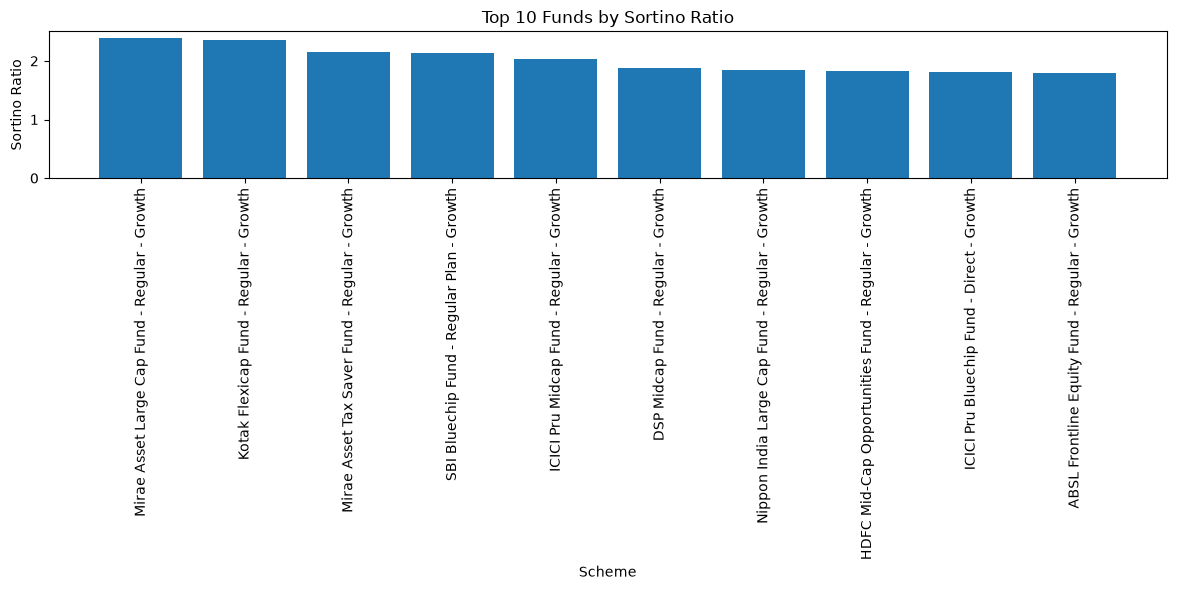

In [23]:
import matplotlib.pyplot as plt

top10 = sortino_df.head(10)

plt.figure(figsize=(12,6))

plt.bar(top10["scheme_name"], top10["Sortino Ratio"])

plt.xticks(rotation=90)

plt.title("Top 10 Funds by Sortino Ratio")

plt.xlabel("Scheme")

plt.ylabel("Sortino Ratio")

plt.tight_layout()

plt.savefig(
    "../reports/charts/sortino_ratio_top10.png",
    dpi=300
)

plt.show()

### Insight 4

Funds with higher Sortino Ratios generated superior returns while minimizing downside risk, making them more attractive to risk-conscious investors.

In [25]:
from scipy.stats import linregress
import numpy as np
import pandas as pd

In [28]:
benchmark = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [30]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark = benchmark.sort_values(["index_name", "date"])

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"]
    .pct_change()
)

In [31]:
benchmark_100 = benchmark[
    benchmark["index_name"] == "Nifty 100"
][["date", "benchmark_return"]]

In [32]:
merged = pd.merge(
    nav,
    benchmark_100,
    on="date",
    how="inner"
)

merged.head()

,amfi_code,date,nav,scheme_name,daily_return,benchmark_return


In [33]:
from scipy.stats import linregress

alpha_beta = []

for scheme, group in merged.groupby("scheme_name"):

    data = group.dropna(subset=["daily_return", "benchmark_return"])

    if len(data) > 30:

        slope, intercept, r, p, stderr = linregress(
            data["benchmark_return"],
            data["daily_return"]
        )

        alpha_beta.append({
            "scheme_name": scheme,
            "Beta": round(slope, 3),
            "Alpha": round(intercept * 252, 3)
        })

alpha_beta_df = pd.DataFrame(alpha_beta)

alpha_beta_df.head()

""


In [34]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

In [42]:
benchmark_100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
][["date", "benchmark_return"]]

In [44]:
merged = pd.merge(
    nav,
    benchmark_100,
    on="date",
    how="inner"
)

print(merged.shape)
merged.head()

(46000, 6)


,amfi_code,date,nav,scheme_name,daily_return,benchmark_return
0,101206,2022-01-03,305.0996,ABSL Frontline Equity Fund - Regular - Growth,NaN,NaN
1,101206,2022-01-04,305.4514,ABSL Frontline Equity Fund - Regular - Growth,0.001153,-0.013540
2,101206,2022-01-05,306.6324,ABSL Frontline Equity Fund - Regular - Growth,0.003866,0.004003
3,101206,2022-01-06,305.9800,ABSL Frontline Equity Fund - Regular - Growth,-0.002128,-0.002935
4,101206,2022-01-07,304.0480,ABSL Frontline Equity Fund - Regular - Growth,-0.006314,0.006150


In [45]:
from scipy.stats import linregress

alpha_beta = []

for scheme, group in merged.groupby("scheme_name"):

    data = group.dropna(subset=["daily_return", "benchmark_return"])

    if len(data) > 30:

        beta, alpha, r, p, std_err = linregress(
            data["benchmark_return"],
            data["daily_return"]
        )

        alpha_beta.append({
            "scheme_name": scheme,
            "Beta": round(beta, 3),
            "Alpha": round(alpha * 252, 3)
        })

alpha_beta_df = pd.DataFrame(alpha_beta)

alpha_beta_df.head()

,scheme_name,Beta,Alpha
0,ABSL Frontline Equity Fund - Regular - Growth,0.021,0.214
1,ABSL Liquid Fund - Regular - Growth,0.000,0.061
2,ABSL Small Cap Fund - Regular - Growth,-0.065,0.109
3,Axis Bluechip Fund - Direct - Growth,0.026,0.082
4,Axis Bluechip Fund - Regular - Growth,0.010,0.069


In [46]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

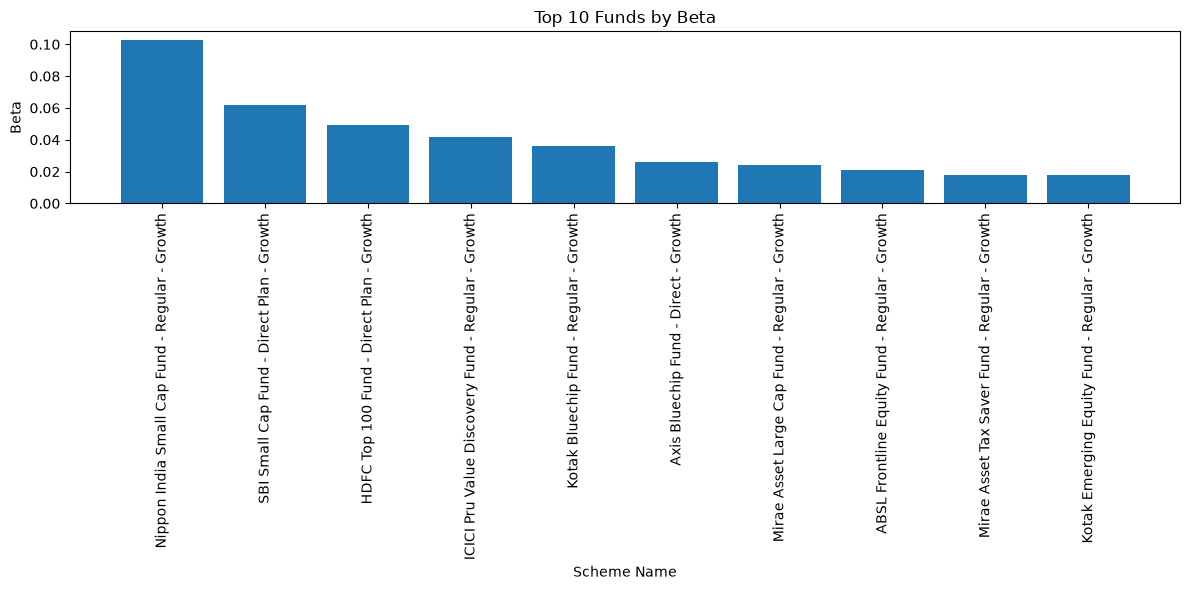

In [47]:
import matplotlib.pyplot as plt

top_beta = alpha_beta_df.sort_values(
    by="Beta",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.bar(top_beta["scheme_name"], top_beta["Beta"])

plt.xticks(rotation=90)

plt.title("Top 10 Funds by Beta")

plt.xlabel("Scheme Name")

plt.ylabel("Beta")

plt.tight_layout()

plt.savefig("../reports/charts/beta_top10.png", dpi=300)

plt.show()

### Insight 5

Funds with Beta greater than 1 are more volatile than the Nifty 100 benchmark, while funds with Beta below 1 are comparatively less sensitive to market movements.

In [61]:


drawdown_results = []

for scheme, group in nav.groupby("scheme_name"):

    group = group.sort_values("date").copy()


    group["running_max"] = group["nav"].cummax()


    group["drawdown"] = (
        group["nav"] / group["running_max"]
    ) - 1

    max_drawdown = group["drawdown"].min()

    worst_date = group.loc[group["drawdown"].idxmin(), "date"]

    drawdown_results.append({
        "scheme_name": scheme,
        "Maximum Drawdown (%)": round(max_drawdown * 100, 2),
        "Worst Date": worst_date
    })

drawdown_df = pd.DataFrame(drawdown_results)

drawdown_df.head()

,scheme_name,Maximum Drawdown (%),Worst Date
0,ABSL Frontline Equity Fund - Regular - Growth,-11.29,2023-07-05
1,ABSL Liquid Fund - Regular - Growth,-0.16,2023-09-12
2,ABSL Small Cap Fund - Regular - Growth,-35.45,2026-05-11
3,Axis Bluechip Fund - Direct - Growth,-21.75,2023-05-22
4,Axis Bluechip Fund - Regular - Growth,-14.40,2025-02-07


In [62]:
drawdown_df.to_csv(
    "../reports/maximum_drawdown.csv",
    index=False
)

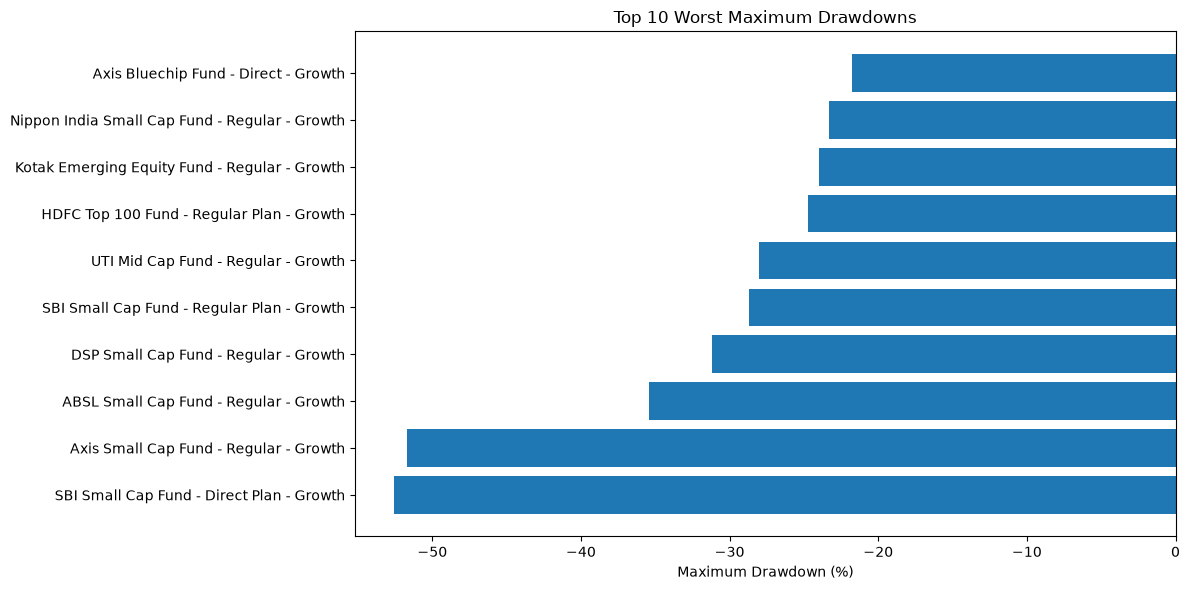

In [64]:
import matplotlib.pyplot as plt

top10 = drawdown_df.sort_values(
    "Maximum Drawdown (%)"
).head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10["scheme_name"],
    top10["Maximum Drawdown (%)"]
)

plt.title("Top 10 Worst Maximum Drawdowns")
plt.xlabel("Maximum Drawdown (%)")

plt.tight_layout()

plt.savefig(
    "../reports/charts/maximum_drawdown.png",
    dpi=300
)

plt.show()

### Insight 6

The Maximum Drawdown metric measures the largest decline in a fund's NAV from its historical peak. Funds with lower maximum drawdowns demonstrated stronger resilience during market downturns, indicating better downside risk management and capital preservation.

In [48]:
expense = fund[["scheme_name", "expense_ratio_pct"]]

In [50]:
drawdown_results = []

for scheme, group in nav.groupby("scheme_name"):

    group = group.sort_values("date").copy()

    group["running_max"] = group["nav"].cummax()

    group["drawdown"] = (
        group["nav"] - group["running_max"]
    ) / group["running_max"]

    max_dd = group["drawdown"].min()

    worst_date = group.loc[group["drawdown"].idxmin(), "date"]

    drawdown_results.append({
        "scheme_name": scheme,
        "Maximum Drawdown (%)": round(max_dd * 100, 2),
        "Worst Date": worst_date
    })

drawdown_df = pd.DataFrame(drawdown_results)

drawdown_df.head()

,scheme_name,Maximum Drawdown (%),Worst Date
0,ABSL Frontline Equity Fund - Regular - Growth,-11.29,2023-07-05
1,ABSL Liquid Fund - Regular - Growth,-0.16,2023-09-12
2,ABSL Small Cap Fund - Regular - Growth,-35.45,2026-05-11
3,Axis Bluechip Fund - Direct - Growth,-21.75,2023-05-22
4,Axis Bluechip Fund - Regular - Growth,-14.40,2025-02-07


In [51]:
drawdown_df.to_csv(
    "../reports/maximum_drawdown.csv",
    index=False
)

In [52]:
expense = fund[["scheme_name", "expense_ratio_pct"]]

scorecard = cagr_df.merge(sharpe_df, on="scheme_name")
scorecard = scorecard.merge(alpha_beta_df, on="scheme_name")
scorecard = scorecard.merge(drawdown_df, on="scheme_name")
scorecard = scorecard.merge(expense, on="scheme_name")

scorecard.head()

,scheme_name,CAGR (%),Sharpe Ratio,Beta,Alpha,Maximum Drawdown (%),Worst Date,expense_ratio_pct
0,ICICI Pru Midcap Fund - Regular - Growth,32.83,1.180,0.001,0.293,-18.19,2025-01-23,1.36
1,SBI Small Cap Fund - Regular Plan - Growth,32.42,0.945,-0.023,0.303,-28.71,2025-05-14,1.43
2,DSP Small Cap Fund - Regular - Growth,32.29,0.950,0.011,0.301,-31.17,2025-01-03,1.52
3,Mirae Asset Tax Saver Fund - Regular - Growth,31.95,1.235,0.018,0.283,-16.40,2023-10-20,1.60
4,Mirae Asset Large Cap Fund - Regular - Growth,30.97,1.448,0.024,0.270,-11.27,2023-10-20,1.46


In [53]:
scorecard["Return Rank"] = scorecard["CAGR (%)"].rank(ascending=False)

scorecard["Sharpe Rank"] = scorecard["Sharpe Ratio"].rank(ascending=False)

scorecard["Alpha Rank"] = scorecard["Alpha"].rank(ascending=False)

scorecard["Expense Rank"] = scorecard["expense_ratio_pct"].rank()

scorecard["Drawdown Rank"] = scorecard["Maximum Drawdown (%)"].rank()

In [54]:
scorecard["Fund Score"] = (
    30 * (1 / scorecard["Return Rank"]) +
    25 * (1 / scorecard["Sharpe Rank"]) +
    20 * (1 / scorecard["Alpha Rank"]) +
    15 * (1 / scorecard["Expense Rank"]) +
    10 * (1 / scorecard["Drawdown Rank"])
)

In [56]:
scorecard["Fund Score"] = (
    scorecard["Fund Score"] /
    scorecard["Fund Score"].max()
) * 100

scorecard["Fund Score"] = scorecard["Fund Score"].round(2)

In [57]:
scorecard = scorecard.sort_values(
    "Fund Score",
    ascending=False
)

scorecard.head(10)

,scheme_name,CAGR (%),Sharpe Ratio,Beta,Alpha,Maximum Drawdown (%),Worst Date,expense_ratio_pct,Return Rank,Sharpe Rank,Alpha Rank,Expense Rank,Drawdown Rank,Fund Score
0,ICICI Pru Midcap Fund - Regular - Growth,32.83,1.180,0.001,0.293,-18.19,2025-01-23,1.36,1.0,5.0,3.0,15.0,16.0,100.00
1,SBI Small Cap Fund - Regular Plan - Growth,32.42,0.945,-0.023,0.303,-28.71,2025-05-14,1.43,2.0,14.0,1.0,21.0,5.0,91.24
4,Mirae Asset Large Cap Fund - Regular - Growth,30.97,1.448,0.024,0.270,-11.27,2023-10-20,1.46,5.0,1.0,7.0,23.0,33.0,80.41
2,DSP Small Cap Fund - Regular - Growth,32.29,0.950,0.011,0.301,-31.17,2025-01-03,1.52,3.0,13.0,2.0,26.5,4.0,57.72
5,Kotak Flexicap Fund - Regular - Growth,30.91,1.307,-0.023,0.273,-12.97,2022-04-13,1.45,6.0,2.0,5.0,22.0,28.0,52.06
3,Mirae Asset Tax Saver Fund - Regular - Growth,31.95,1.235,0.018,0.283,-16.40,2023-10-20,1.60,4.0,3.0,4.0,36.5,20.0,50.23
34,Nippon India Gilt Securities Fund - Regular - ...,5.32,-0.357,0.001,0.051,-8.32,2024-02-09,0.55,35.0,38.0,35.0,1.0,35.0,40.13
37,SBI Small Cap Fund - Direct Plan - Growth,2.05,-0.057,0.062,0.049,-52.57,2025-10-28,0.72,38.0,32.0,36.0,5.5,1.0,34.31
6,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,30.12,1.094,0.005,0.272,-16.22,2022-05-12,1.38,7.0,7.0,6.0,17.0,21.0,28.99
9,SBI Bluechip Fund - Regular Plan - Growth,25.80,1.208,-0.032,0.232,-15.01,2024-02-05,1.54,10.0,4.0,10.0,30.5,24.0,28.09


In [58]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

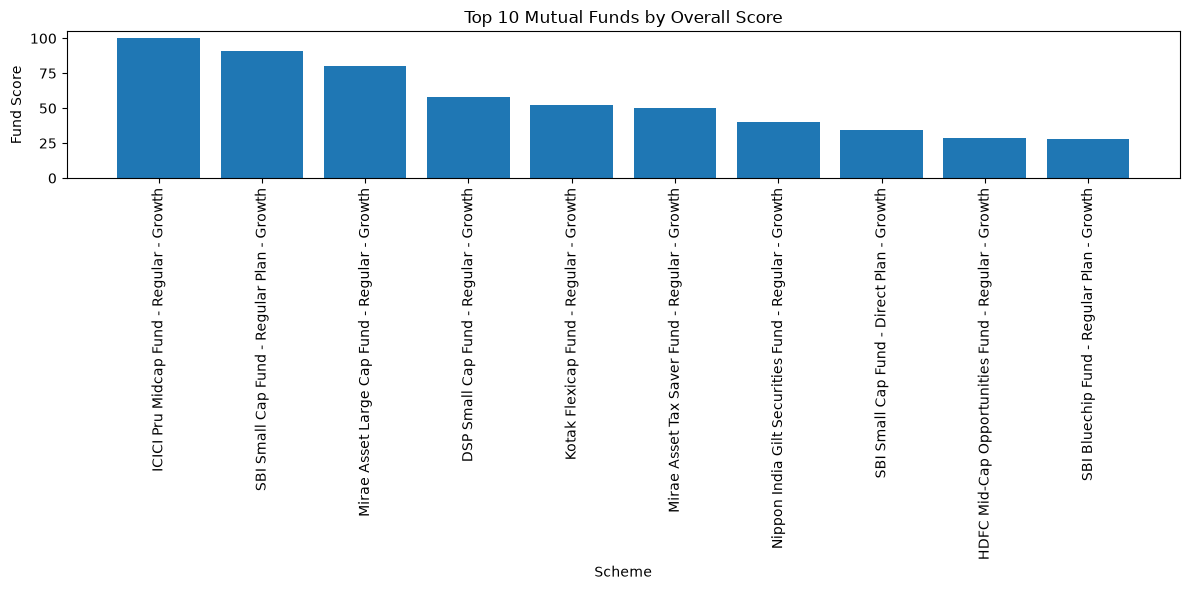

In [59]:
import matplotlib.pyplot as plt

top10 = scorecard.head(10)

plt.figure(figsize=(12,6))

plt.bar(top10["scheme_name"], top10["Fund Score"])

plt.xticks(rotation=90)

plt.title("Top 10 Mutual Funds by Overall Score")

plt.xlabel("Scheme")

plt.ylabel("Fund Score")

plt.tight_layout()

plt.savefig(
    "../reports/charts/fund_scorecard.png",
    dpi=300
)

plt.show()

### Insight 7

The Fund Score combines return, risk-adjusted performance, alpha generation, expense efficiency, and downside protection into a single composite score for ranking mutual funds.

In [65]:
top5 = scorecard.head(5)["scheme_name"].tolist()

top5

['ICICI Pru Midcap Fund - Regular - Growth',
 'SBI Small Cap Fund - Regular Plan - Growth',
 'Mirae Asset Large Cap Fund - Regular - Growth',
 'DSP Small Cap Fund - Regular - Growth',
 'Kotak Flexicap Fund - Regular - Growth']

In [66]:
top5_nav = nav[
    nav["scheme_name"].isin(top5)
].copy()

In [67]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

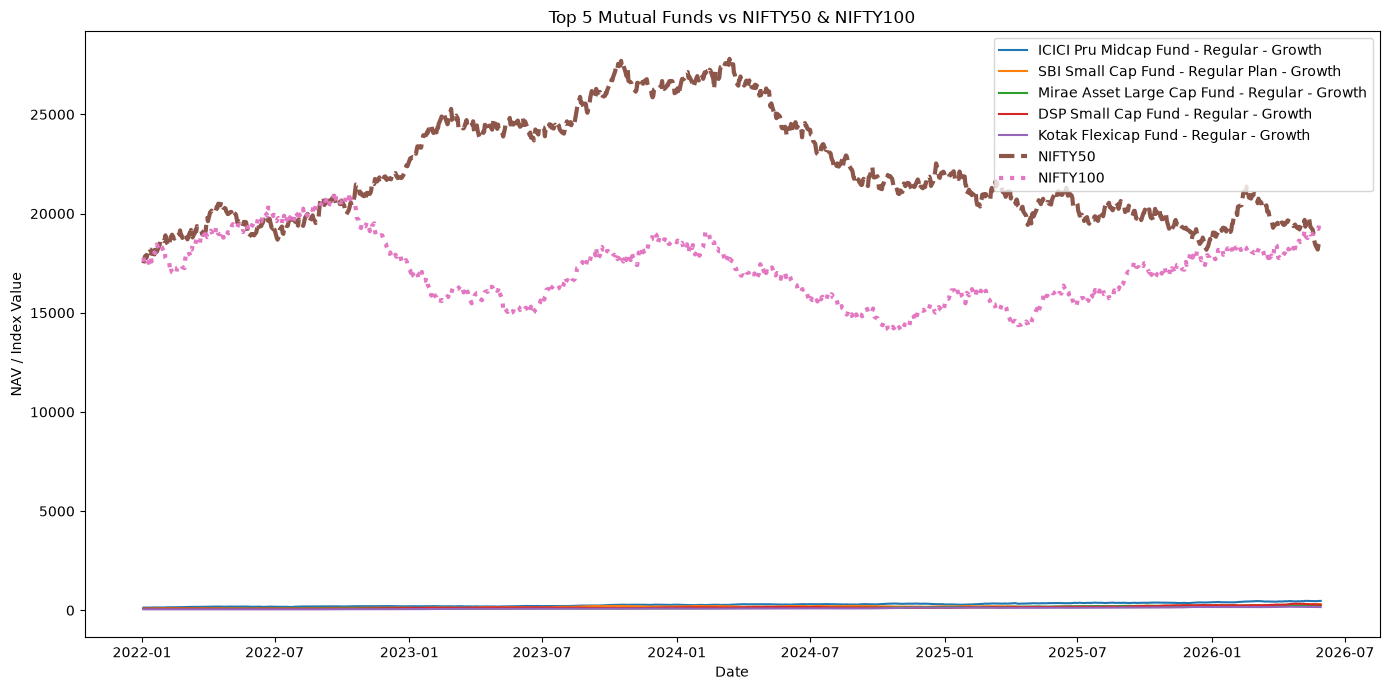

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

# Top 5 Funds
for scheme in top5:
    data = top5_nav[top5_nav["scheme_name"] == scheme]
    plt.plot(data["date"], data["nav"], label=scheme)

# NIFTY50
plt.plot(
    nifty50["date"],
    nifty50["close_value"],
    linewidth=3,
    linestyle="--",
    label="NIFTY50"
)

# NIFTY100
plt.plot(
    nifty100["date"],
    nifty100["close_value"],
    linewidth=3,
    linestyle=":",
    label="NIFTY100"
)

plt.title("Top 5 Mutual Funds vs NIFTY50 & NIFTY100")

plt.xlabel("Date")

plt.ylabel("NAV / Index Value")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/charts/benchmark_comparison.png",
    dpi=300
)

plt.show()

In [70]:
tracking_error = []

for scheme in top5:

    fund_data = top5_nav[
        top5_nav["scheme_name"] == scheme
    ].copy()

    fund_data["fund_return"] = fund_data["nav"].pct_change()

    merged = pd.merge(
        fund_data,
        benchmark_100,
        on="date",
        how="inner"
    )

    te = (
        (merged["fund_return"] - merged["benchmark_return"])
        .std()
        * (252 ** 0.5)
    )

    tracking_error.append({
        "scheme_name": scheme,
        "Tracking Error": round(te, 4)
    })

tracking_error_df = pd.DataFrame(tracking_error)

tracking_error_df

,scheme_name,Tracking Error
0,ICICI Pru Midcap Fund - Regular - Growth,0.2320
1,SBI Small Cap Fund - Regular Plan - Growth,0.2839
2,Mirae Asset Large Cap Fund - Regular - Growth,0.1897
3,DSP Small Cap Fund - Regular - Growth,0.2792
4,Kotak Flexicap Fund - Regular - Growth,0.2064


In [71]:
tracking_error_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

### Insight 8

Benchmark comparison shows how closely each fund tracks the market indices. Funds with lower tracking error follow the benchmark more consistently, while higher tracking error indicates greater deviation due to active fund management.